In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings; warnings.filterwarnings('ignore')

from sklearn.datasets import load_digits
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import (accuracy_score, f1_score, classification_report,
                              confusion_matrix, ConfusionMatrixDisplay)
RANDOM_STATE = 42; np.random.seed(RANDOM_STATE)
print("Imports done.")

Imports done.


---
## Part A
### A1 — Load Digits

Shape: (1797, 64)  |  Classes: [0 1 2 3 4 5 6 7 8 9]


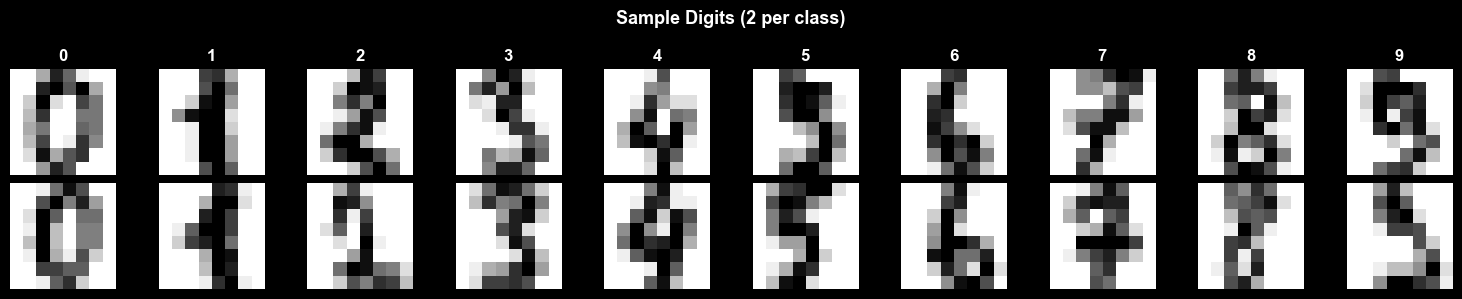

In [2]:
digits = load_digits()
X, y = digits.data, digits.target
print(f"Shape: {X.shape}  |  Classes: {np.unique(y)}")

fig, axes = plt.subplots(2, 10, figsize=(15, 3))
for d in range(10):
    for row in range(2):
        idx = np.where(y == d)[0][row]
        axes[row, d].imshow(digits.images[idx], cmap='gray_r')
        if row == 0: axes[row, d].set_title(str(d), fontweight='bold')
        axes[row, d].axis('off')
plt.suptitle('Sample Digits (2 per class)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('digits_samples.png', dpi=120, bbox_inches='tight')
plt.show()

### A2 — Scale & Split

In [3]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y)
scaler = StandardScaler()
Xtr_sc = scaler.fit_transform(X_train)
Xte_sc = scaler.transform(X_test)
print(f"Train: {len(X_train)}  Test: {len(X_test)}")

Train: 1437  Test: 360


### A3 — SVM (RBF) + GridSearchCV

In [4]:
param_grid = {'C': [0.1, 1, 10, 100], 'gamma': [0.001, 0.01, 0.1, 'scale']}
svm_gs = GridSearchCV(SVC(kernel='rbf', random_state=RANDOM_STATE),
                      param_grid, cv=5, scoring='accuracy', n_jobs=-1, verbose=1)
svm_gs.fit(Xtr_sc, y_train)
best_svm = svm_gs.best_estimator_
print(f"Best params: {svm_gs.best_params_}  |  CV acc: {svm_gs.best_score_:.4f}")

Fitting 5 folds for each of 16 candidates, totalling 80 fits
Best params: {'C': 100, 'gamma': 0.01}  |  CV acc: 0.9833


In [5]:
svm_preds = best_svm.predict(Xte_sc)
svm_acc = accuracy_score(y_test, svm_preds)
print(f"SVM Test Accuracy: {svm_acc:.4f}\n")
print(classification_report(y_test, svm_preds))

SVM Test Accuracy: 0.9833

              precision    recall  f1-score   support

           0       1.00      1.00      1.00        36
           1       0.97      0.97      0.97        36
           2       1.00      1.00      1.00        35
           3       1.00      1.00      1.00        37
           4       0.95      0.97      0.96        36
           5       1.00      1.00      1.00        37
           6       0.97      1.00      0.99        36
           7       0.95      1.00      0.97        36
           8       1.00      0.94      0.97        35
           9       1.00      0.94      0.97        36

    accuracy                           0.98       360
   macro avg       0.98      0.98      0.98       360
weighted avg       0.98      0.98      0.98       360



### A4 — KNN: Find Optimal K

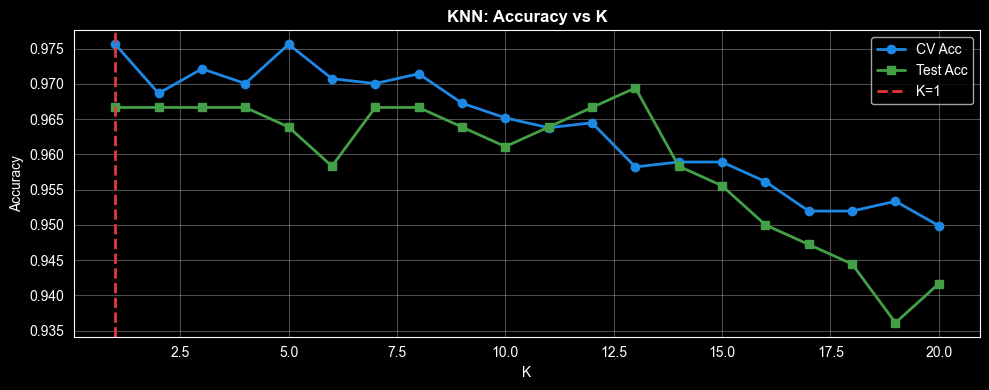

Optimal K=1  CV acc=0.9756


In [6]:
k_range, k_cv_accs, k_test_accs = range(1, 21), [], []
for k in k_range:
    knn = KNeighborsClassifier(n_neighbors=k, n_jobs=-1)
    k_cv_accs.append(cross_val_score(knn, Xtr_sc, y_train, cv=5).mean())
    knn.fit(Xtr_sc, y_train)
    k_test_accs.append(accuracy_score(y_test, knn.predict(Xte_sc)))

optimal_k = list(k_range)[np.argmax(k_cv_accs)]
plt.figure(figsize=(10, 4))
plt.plot(k_range, k_cv_accs,   'o-', color='#1E88E5', label='CV Acc',   lw=2)
plt.plot(k_range, k_test_accs, 's-', color='#43A047', label='Test Acc', lw=2)
plt.axvline(optimal_k, color='#E53935', ls='--', lw=2, label=f'K={optimal_k}')
plt.xlabel('K'); plt.ylabel('Accuracy'); plt.title('KNN: Accuracy vs K', fontweight='bold')
plt.legend(); plt.grid(alpha=0.3); plt.tight_layout()
plt.savefig('knn_k_selection.png', dpi=120, bbox_inches='tight'); plt.show()
print(f"Optimal K={optimal_k}  CV acc={max(k_cv_accs):.4f}")

In [7]:
best_knn = KNeighborsClassifier(n_neighbors=optimal_k, n_jobs=-1)
best_knn.fit(Xtr_sc, y_train)
knn_preds = best_knn.predict(Xte_sc)
knn_acc = accuracy_score(y_test, knn_preds)
print(f"KNN (K={optimal_k}) Test Accuracy: {knn_acc:.4f}\n")
print(classification_report(y_test, knn_preds))

KNN (K=1) Test Accuracy: 0.9667

              precision    recall  f1-score   support

           0       1.00      1.00      1.00        36
           1       0.92      0.97      0.95        36
           2       0.97      0.97      0.97        35
           3       0.97      1.00      0.99        37
           4       0.97      0.94      0.96        36
           5       0.97      1.00      0.99        37
           6       0.97      1.00      0.99        36
           7       0.95      0.97      0.96        36
           8       0.94      0.89      0.91        35
           9       1.00      0.92      0.96        36

    accuracy                           0.97       360
   macro avg       0.97      0.97      0.97       360
weighted avg       0.97      0.97      0.97       360



### A5 — Comparison: Metrics + Confusion Matrices

 Digit  SVM F1  KNN F1
     0  1.0000  1.0000
     1  0.9722  0.9459
     2  1.0000  0.9714
     3  1.0000  0.9867
     4  0.9589  0.9577
     5  1.0000  0.9867
     6  0.9863  0.9863
     7  0.9730  0.9589
     8  0.9706  0.9118
     9  0.9714  0.9565


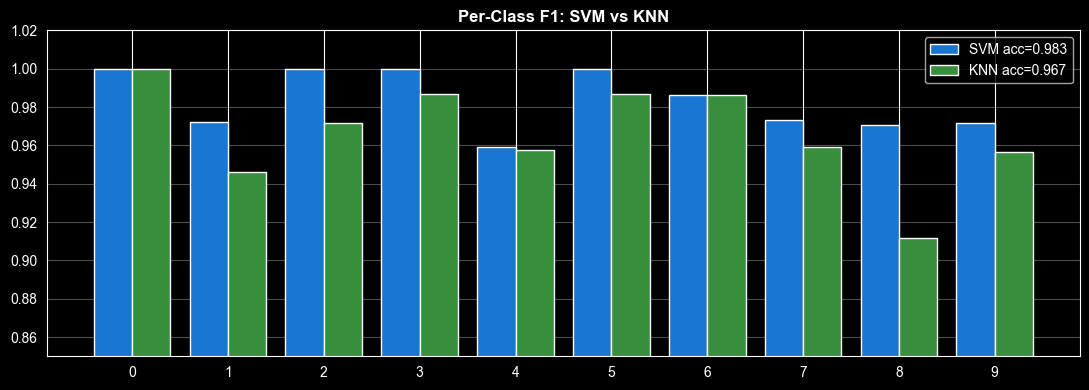

In [8]:
svm_f1 = f1_score(y_test, svm_preds, average=None)
knn_f1 = f1_score(y_test, knn_preds, average=None)
f1_df = pd.DataFrame({'Digit': list(range(10)), 'SVM F1': svm_f1.round(4), 'KNN F1': knn_f1.round(4)})
print(f1_df.to_string(index=False))

fig, ax = plt.subplots(figsize=(11, 4))
x = np.arange(10)
ax.bar(x-0.2, svm_f1, 0.4, label=f'SVM acc={svm_acc:.3f}', color='#1976D2')
ax.bar(x+0.2, knn_f1, 0.4, label=f'KNN acc={knn_acc:.3f}', color='#388E3C')
ax.set_xticks(x); ax.set_xticklabels(range(10))
ax.set_title('Per-Class F1: SVM vs KNN', fontweight='bold')
ax.set_ylim(0.85, 1.02); ax.legend(); ax.grid(axis='y', alpha=0.3)
plt.tight_layout(); plt.savefig('per_class_f1.png', dpi=120, bbox_inches='tight'); plt.show()

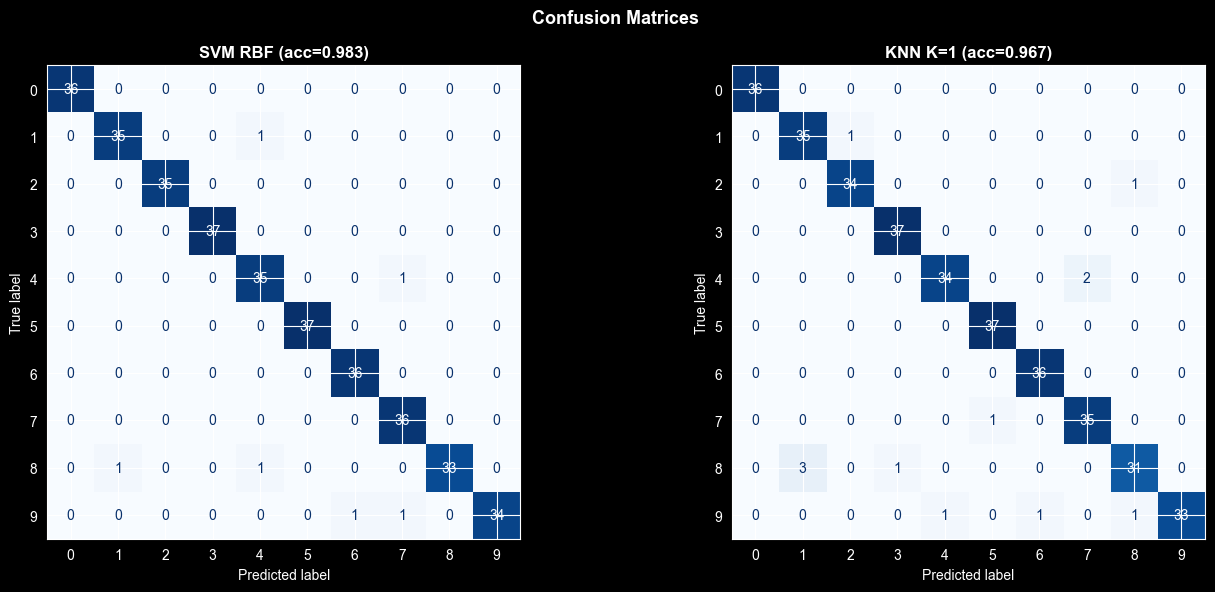

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
for ax, preds, title in zip(axes,
    [svm_preds, knn_preds],
    [f'SVM RBF (acc={svm_acc:.3f})', f'KNN K={optimal_k} (acc={knn_acc:.3f})']):
    ConfusionMatrixDisplay(confusion_matrix(y_test, preds), display_labels=range(10)
                           ).plot(ax=ax, colorbar=False, cmap='Blues')
    ax.set_title(title, fontweight='bold')
plt.suptitle('Confusion Matrices', fontsize=13, fontweight='bold')
plt.tight_layout(); plt.savefig('confusion_matrices_digits.png', dpi=120, bbox_inches='tight'); plt.show()

### A6 — Most Confused Pairs

In [10]:
def top_confused_pairs(y_true, y_pred, top_n=5):
    cm = confusion_matrix(y_true, y_pred); np.fill_diagonal(cm, 0)
    pairs = [{'True': i, 'Predicted': j, 'Count': cm[i,j]}
             for i in range(10) for j in range(10) if i!=j and cm[i,j]>0]
    return pd.DataFrame(pairs).sort_values('Count', ascending=False).head(top_n)

print("SVM:"); print(top_confused_pairs(y_test, svm_preds).to_string(index=False))
print("\nKNN:"); print(top_confused_pairs(y_test, knn_preds).to_string(index=False))
print("""
Typical confusion pairs:
  3 vs 8 -> similar curved strokes at 8x8 resolution
  4 vs 9 -> upper loop of 9 resembles 4
  1 vs 7 -> diagonal stroke of 7 can look like 1
""")

SVM:
 True  Predicted  Count
    1          4      1
    4          7      1
    8          1      1
    8          4      1
    9          6      1

KNN:
 True  Predicted  Count
    8          1      3
    4          7      2
    1          2      1
    2          8      1
    7          5      1

Typical confusion pairs:
  3 vs 8 -> similar curved strokes at 8x8 resolution
  4 vs 9 -> upper loop of 9 resembles 4
  1 vs 7 -> diagonal stroke of 7 can look like 1



---
##  Part B

In [11]:
import faiss, time as _time

Xtr_f32 = Xtr_sc.astype(np.float32)
Xte_f32 = Xte_sc.astype(np.float32)
d = Xtr_f32.shape[1]

index = faiss.IndexFlatL2(d)
index.add(Xtr_f32)
print(f"FAISS index: {index.ntotal} vectors, dim={d}")

K, N = optimal_k, 1000

t0 = _time.perf_counter()
_, nn_idx = index.search(Xte_f32[:N], K)
faiss_time = _time.perf_counter() - t0
faiss_preds = np.array([np.bincount(y_train[idx]).argmax() for idx in nn_idx])
faiss_acc = accuracy_score(y_test[:N], faiss_preds)

t0 = _time.perf_counter()
sk_preds_q = best_knn.predict(Xte_sc[:N])
sk_time = _time.perf_counter() - t0
sk_acc = accuracy_score(y_test[:N], sk_preds_q)

print(f"\n{'Method':<20} {'Time (s)':>10} {'Accuracy':>10}")
print("-"*42)
print(f"{'sklearn KNN':<20} {sk_time:>10.4f} {sk_acc:>10.4f}")
print(f"{'FAISS (exact)':<20} {faiss_time:>10.4f} {faiss_acc:>10.4f}")
print(f"\nFAISS speedup: {sk_time/faiss_time:.1f}x")

FAISS index: 1437 vectors, dim=64

Method                 Time (s)   Accuracy
------------------------------------------
sklearn KNN              0.0049     0.9667
FAISS (exact)            0.0016     0.9667

FAISS speedup: 3.0x


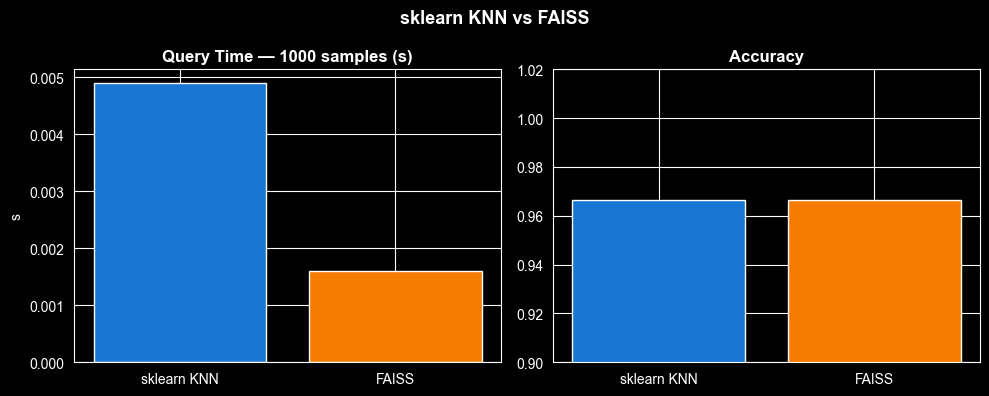


Findings:
  - FAISS IndexFlatL2 = exact NN search via BLAS/SIMD optimisation -> same accuracy, faster.
  - At billion scale, approximate indexes (IVFFlat, HNSW) give sub-ms latency.
  - RAG pipelines (LlamaIndex, LangChain) rely on FAISS for embedding similarity search.



In [12]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
methods = ['sklearn KNN','FAISS']
axes[0].bar(methods, [sk_time, faiss_time], color=['#1976D2','#F57C00'])
axes[0].set_title('Query Time — 1000 samples (s)', fontweight='bold'); axes[0].set_ylabel('s')
axes[1].bar(methods, [sk_acc, faiss_acc], color=['#1976D2','#F57C00'])
axes[1].set_title('Accuracy', fontweight='bold'); axes[1].set_ylim(0.9, 1.02)
plt.suptitle('sklearn KNN vs FAISS', fontsize=13, fontweight='bold')
plt.tight_layout(); plt.savefig('faiss_comparison.png', dpi=120, bbox_inches='tight'); plt.show()
print("""
Findings:
  - FAISS IndexFlatL2 = exact NN search via BLAS/SIMD optimisation -> same accuracy, faster.
  - At billion scale, approximate indexes (IVFFlat, HNSW) give sub-ms latency.
  - RAG pipelines (LlamaIndex, LangChain) rely on FAISS for embedding similarity search.
""")

---
##  Part C
### Q1 — SVM vs Logistic Regression

In [13]:
print("""
SVM vs Logistic Regression (linear kernel — same hyperplane, different objective)
==================================================================================
Logistic Regression
  Objective : Minimise cross-entropy (max log-likelihood)
  Influence : ALL points contribute via gradient, weighted by P(y|x)
  Output    : Calibrated probabilities
  Best when : Need probability scores, large datasets (SGD scales well)

SVM (Linear)
  Objective : Maximise margin = 2/||w||
  Influence : Only SUPPORT VECTORS matter; all other points are irrelevant
  Output    : Class label (Platt scaling for probabilities)
  Best when : Near-linearly-separable, high-dim sparse (text), smaller datasets

Key insight: LR minimises loss for all points equally.
             SVM actively ignores non-support-vector points after the margin is found.
""")


SVM vs Logistic Regression (linear kernel — same hyperplane, different objective)
Logistic Regression
  Objective : Minimise cross-entropy (max log-likelihood)
  Influence : ALL points contribute via gradient, weighted by P(y|x)
  Output    : Calibrated probabilities
  Best when : Need probability scores, large datasets (SGD scales well)

SVM (Linear)
  Objective : Maximise margin = 2/||w||
  Influence : Only SUPPORT VECTORS matter; all other points are irrelevant
  Output    : Class label (Platt scaling for probabilities)
  Best when : Near-linearly-separable, high-dim sparse (text), smaller datasets

Key insight: LR minimises loss for all points equally.
             SVM actively ignores non-support-vector points after the margin is found.



### Q2 — `knn_from_scratch()` (NumPy only)

In [14]:
def knn_from_scratch(X_train, y_train, X_test, k):
    """KNN using only NumPy. Euclidean distance + majority vote."""
    preds = np.empty(len(X_test), dtype=y_train.dtype)
    for i, q in enumerate(X_test):
        sq_dists  = np.sum((X_train - q) ** 2, axis=1)    # (n_train,)
        k_nearest = np.argpartition(sq_dists, k)[:k]       # O(n) top-k
        preds[i]  = np.bincount(y_train[k_nearest]).argmax()
    return preds

scratch = knn_from_scratch(Xtr_sc, y_train, Xte_sc[:200], k=optimal_k)
sk_ref  = best_knn.predict(Xte_sc[:200])
print(f"Scratch acc : {accuracy_score(y_test[:200], scratch):.4f}")
print(f"sklearn acc : {accuracy_score(y_test[:200], sk_ref):.4f}")
print(f"Match       : {np.array_equal(scratch, sk_ref)}")

Scratch acc : 0.9650
sklearn acc : 0.9650
Match       : True


### Q3 — Debug: SVM 0.50 accuracy

In [15]:
print("""
Root Cause: UNSCALED FEATURES
==============================
salary range : 50,000 - 200,000 -> squared differences ~ 150,000^2
age range    : 20 - 60          -> squared differences ~ 40^2

RBF kernel K(x,x') = exp(-gamma * ||x-x'||^2) is dominated entirely by salary.
Age is effectively invisible -> the kernel sees only one feature -> random boundary.

Fix:
  scaler  = StandardScaler()
  X_tr_sc = scaler.fit_transform(X_train)  # fit ONLY on train
  X_te_sc = scaler.transform(X_test)
  svm = SVC(kernel='rbf', C=1.0)
  svm.fit(X_tr_sc, y_train)

Rule: ALWAYS scale before SVM, KNN, PCA, or any distance-based model.
""")


Root Cause: UNSCALED FEATURES
salary range : 50,000 - 200,000 -> squared differences ~ 150,000^2
age range    : 20 - 60          -> squared differences ~ 40^2

RBF kernel K(x,x') = exp(-gamma * ||x-x'||^2) is dominated entirely by salary.
Age is effectively invisible -> the kernel sees only one feature -> random boundary.

Fix:
  scaler  = StandardScaler()
  X_tr_sc = scaler.fit_transform(X_train)  # fit ONLY on train
  X_te_sc = scaler.transform(X_test)
  svm = SVC(kernel='rbf', C=1.0)
  svm.fit(X_tr_sc, y_train)

Rule: ALWAYS scale before SVM, KNN, PCA, or any distance-based model.



---
##  Part D


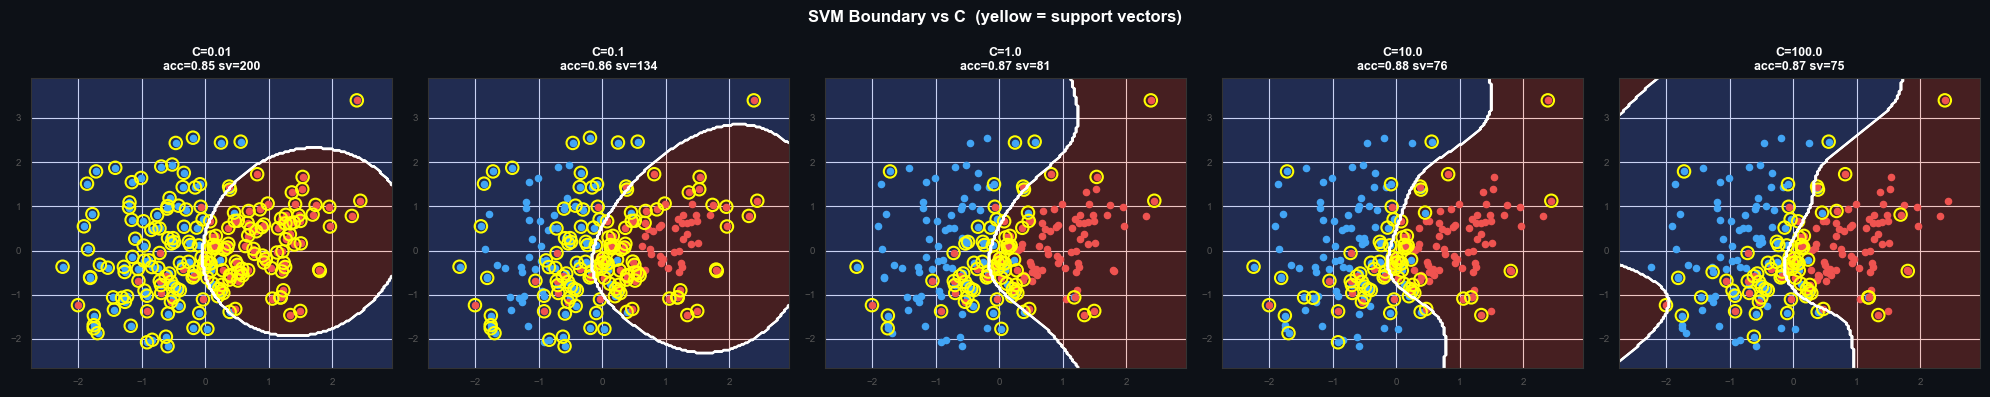


C = 0.01 -> Wide margin, many misclassifications, underfitting
C = 100  -> Narrow margin, tries to fit all points, overfitting risk
Optimal C balances margin width vs training error.



In [16]:
from sklearn.datasets import make_classification

X2, y2 = make_classification(n_samples=200, n_features=2, n_redundant=0,
                               n_informative=2, random_state=42, n_clusters_per_class=1)
X2_sc = StandardScaler().fit_transform(X2)
C_values = [0.01, 0.1, 1.0, 10.0, 100.0]

fig, axes = plt.subplots(1, 5, figsize=(20, 4))
fig.patch.set_facecolor('#0D1117')
for ax, C in zip(axes, C_values):
    clf = SVC(kernel='rbf', C=C, gamma='scale').fit(X2_sc, y2)
    x0,x1 = X2_sc[:,0].min()-0.5, X2_sc[:,0].max()+0.5
    y0,y1 = X2_sc[:,1].min()-0.5, X2_sc[:,1].max()+0.5
    xx,yy = np.meshgrid(np.linspace(x0,x1,200), np.linspace(y0,y1,200))
    Z = clf.predict(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)
    ax.set_facecolor('#0D1117')
    ax.contourf(xx, yy, Z, alpha=0.3, cmap='coolwarm')
    ax.contour(xx, yy, Z, colors='white', linewidths=1)
    ax.scatter(X2_sc[y2==0,0], X2_sc[y2==0,1], c='#42A5F5', s=20)
    ax.scatter(X2_sc[y2==1,0], X2_sc[y2==1,1], c='#EF5350', s=20)
    sv = clf.support_vectors_
    ax.scatter(sv[:,0], sv[:,1], s=80, facecolors='none', edgecolors='yellow', lw=1.5)
    acc = accuracy_score(y2, clf.predict(X2_sc))
    ax.set_title(f'C={C}\nacc={acc:.2f} sv={len(sv)}', color='white', fontsize=9, fontweight='bold')
    for sp in ax.spines.values(): sp.set_edgecolor('#333')
    ax.tick_params(colors='#555', labelsize=7)
plt.suptitle('SVM Boundary vs C  (yellow = support vectors)', color='white', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('svm_C_tradeoff.png', dpi=130, bbox_inches='tight', facecolor='#0D1117')
plt.show()
print("""
C = 0.01 -> Wide margin, many misclassifications, underfitting
C = 100  -> Narrow margin, tries to fit all points, overfitting risk
Optimal C balances margin width vs training error.
""")

**Kernel Trick Analogy + Critique:**

> Red and blue marbles mixed on a table — no straight line separates them. The kernel trick *lifts* them into 3D: reds float up, blues stay low. A flat plane now separates them cleanly. Projected back to 2D that plane becomes a curved boundary. SVM never computes the actual 3D coordinates — the kernel function computes *dot products in that space directly*, which is mathematically identical but far cheaper.

**Critique:** Accurate for polynomial kernels (finite-dim lift). For RBF, the mapping is to **infinite-dimensional** Hilbert space — the "3D" analogy understates the power. Also, the trick requires SVM's dual formulation (all operations expressed as dot products); it's not universally applicable to other algorithms.
